# Complete Unified Surface-Oxide-Metal Permeation Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys

# Add parent directory to path
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
# =============================================================================
# CELL 1 — SETUP
# Run once. All imports and helper functions.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import pandas as pd
from itertools import groupby
from operator import itemgetter
from IPython.display import display

from calculations.surface_kinetics import (
    calculate_full_model_flux_L346_v2,
    calculate_mixed_defect_flux_L6,
    calculate_defective_metal_flux_L6,
    solve_steady_state_flux_direct,
)
from calculations.config.model_analysis_config import (
    R, F,
    METALS, OXIDES, CONDITIONS, VALIDATION, MICROSTRUCTURE,
    PLOT_STYLE as STYLE,
    CURVE_STYLES,
    apply_style,
    build_simulation_config,
)

# ── Simulation config ─────────────────────────────────────────────────────────
SIM       = build_simulation_config(
    metal='metal_316L_Heat_treated_ref_cast',
    oxide='Al2O3',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

METAL_KEY = SIM['metal_name']
OXIDE_KEY = SIM['oxide_name']
METAL     = METALS[METAL_KEY]
OXIDE     = OXIDES[OXIDE_KEY]
SK_OX     = OXIDE['surface_kinetics']
SK_M      = METAL['surface_kinetics']

# ── Pressure sweep ────────────────────────────────────────────────────────────
P_RANGE_ARR = np.logspace(0, 12, 40)
P_DOWN      = SIM['P_downstream']
T_RANGE     = CONDITIONS['T_range']
N_T         = CONDITIONS['n_T_points']

# ── Arrhenius helpers — oxide surface ────────────────────────────────────────
def get_k_diss_at_T(T_K):
    return SK_OX['k_diss_ref'] * np.exp(
        (-SK_OX['E_diss'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_K_eq_at_T(T_K):
    return SK_OX['K_eq_ref'] * np.exp(
        (-SK_OX['H_eq'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_D_ox_at_T(T_K):
    return OXIDE['D_ox_ref'] * np.exp(
        (-OXIDE['E_D_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

def get_K_ox_at_T(T_K):
    return OXIDE['K_ox_ref'] * np.exp(
        (-OXIDE['H_sol_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

# ── Arrhenius helpers — metal ────────────────────────────────────────────────
def get_D_m_at_T(T_K):
    return METAL['D_ref'] * np.exp(
        (-METAL['E_D'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_K_s_m_at_T(T_K):
    return METAL['K_s_ref'] * np.exp(
        (-METAL['H_s'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_k_diss_metal_at_T(T_K):
    return SK_M['k_diss_metal_ref'] * np.exp(
        (-SK_M['E_diss_metal'] / R) * (1/T_K - 1/SK_M['T_ref'])
    )

def get_K_eq_metal_at_T(T_K):
    return SK_M['K_eq_metal_ref'] * np.exp(
        (-SK_M['H_eq_metal'] / R) * (1/T_K - 1/SK_M['T_ref'])
    )

# ── D_eff helper ──────────────────────────────────────────────────────────────
def get_D_eff_at_T(T_K, mode, microstructure):
    try:
        r = calculate_defective_metal_flux_L6(
            1e5, 0, SIM['L_metal'], T_K,
            get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
            get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), SIM['L_oxide'],
            get_D_m_at_T(T_K),    get_K_s_m_at_T(T_K),
            microstructure_params=microstructure,
            mode=mode,
        )
        return r.get('D_eff', get_D_m_at_T(T_K))
    except Exception:
        return get_D_m_at_T(T_K)

# ── Reference activation energies ────────────────────────────────────────────
E_REF_SURFACE = SK_OX['E_diss']
E_REF_OXIDE   = OXIDE['E_D_ox'] + OXIDE['H_sol_ox']
E_REF_METAL   = METAL['E_D']    + METAL['H_s']

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)
print(f"  Metal:         {METAL_KEY}")
print(f"  Oxide:         {OXIDE_KEY}")
print(f"  E_ref surface: {E_REF_SURFACE/1000:.1f} kJ/mol")
print(f"  E_ref oxide:   {E_REF_OXIDE/1000:.1f} kJ/mol")
print(f"  E_ref metal:   {E_REF_METAL/1000:.1f} kJ/mol")
print(f"  P range:       {P_RANGE_ARR[0]:.0e} – {P_RANGE_ARR[-1]:.0e} Pa")
print(f"  T range:       {T_RANGE[0]} – {T_RANGE[1]} K")
print("=" * 60)

SETUP COMPLETE
  Metal:         metal_316L_Heat_treated_ref_cast
  Oxide:         Al2O3
  E_ref surface: 50.0 kJ/mol
  E_ref oxide:   318.2 kJ/mol
  E_ref metal:   63.1 kJ/mol
  P range:       1e+00 – 1e+12 Pa
  T range:       623 – 1200 K


In [3]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# Change values in config and rerun from this cell downward.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
L_m    = SIM['L_metal']
P_down = SIM['P_downstream']

# ── Surface kinetics at T_op ──────────────────────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Metal lattice transport at T_op ───────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_m_at_T(T_op)

# ── Microstructure — from config ──────────────────────────────────────────────
microstructure = SIM['microstructure']
mode           = microstructure.get('mode', 'both')
grain_size     = microstructure['grain_size']
gb_thickness   = microstructure['gb_thickness']
gb_type        = microstructure.get('gb_type', 'LAGB')
lattice_density= microstructure['lattice_density']
trap_list      = microstructure['trap_list']

# ── D_eff at T_op — all four modes (correct mode strings) ────────────────────
D_eff_modes = {}
for m in ('none', 'gb_only', 'trapping_only', 'both'):
    D_eff_modes[m] = get_D_eff_at_T(T_op, m, microstructure)

D_eff = D_eff_modes[mode]    # operating mode D_eff

# ── Derived permeances ────────────────────────────────────────────────────────
alpha    = D_ox  * K_ox / L_ox
beta_L   = D_m   * K_s_m / L_m    # lattice only
beta_eff = D_eff * K_s_m / L_m    # effective (with microstructure)

# ── Validation sweep parameters — from config ─────────────────────────────────
VAL_L4           = VALIDATION['L4']
grain_size_sweep = VAL_L4['grain_size']
T_grain_size     = VAL_L4['T_grain_size']

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L2+L4+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox     = {L_ox:.3e}  m")
print(f"    L_m      = {L_m:.3e}  m")
print(f"    P_down   = {P_down:.1e}  Pa")

print(f"\n  Surface kinetics  [config: oxide surface_kinetics]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")
print(f"    k_recomb = {k_recomb:.3e}  mol/m²/s")

print(f"\n  Oxide transport  [config: Arrhenius]")
print(f"    D_ox     = {D_ox:.3e}  m²/s")
print(f"    K_ox     = {K_ox:.3e}  mol/m³/Pa^0.5")

print(f"\n  Metal lattice transport  [config: Arrhenius]")
print(f"    D_m      = {D_m:.3e}  m²/s")
print(f"    K_s_m    = {K_s_m:.3e}  mol/m³/Pa^0.5")

print(f"\n  Microstructure  [config: MICROSTRUCTURE]")
print(f"    mode             = {mode}")
print(f"    grain_size       = {grain_size*1e6:.1f} μm")
print(f"    gb_thickness     = {gb_thickness*1e9:.1f} nm")
print(f"    gb_type          = {gb_type}")
print(f"    lattice_density  = {lattice_density:.3e}  m⁻³")
print(f"    traps:")
for trap in trap_list:
    print(f"      {trap['name']:<20} "
          f"E_b = {trap['binding_energy']/F:.2f} eV  "
          f"n = {trap['density']:.2e} m⁻³")

print(f"\n  D_eff at T_op — all modes")
for m, D in D_eff_modes.items():
    ratio  = D / D_m
    marker = ' ← active' if m == mode else ''
    print(f"    mode={m:<14}  D_eff = {D:.3e} m²/s  "
          f"D_eff/D_m = {ratio:.4f}{marker}")

print(f"\n  Derived permeances")
print(f"    α        = {alpha:.3e}  mol/m²/s/Pa^0.5  (oxide)")
print(f"    β_latt   = {beta_L:.3e}  mol/m²/s/Pa^0.5  (lattice only)")
print(f"    β_eff    = {beta_eff:.3e}  mol/m²/s/Pa^0.5  (mode={mode})")
print(f"    α/β_eff  = {alpha/beta_eff:.3e}")

print(f"\n  Reference activation energies  [config]")
print(f"    E_diss        = {E_REF_SURFACE/1000:.1f} kJ/mol")
print(f"    E_D_ox+H_sol  = {E_REF_OXIDE/1000:.1f} kJ/mol")
print(f"    E_D+H_s       = {E_REF_METAL/1000:.1f} kJ/mol")

if mode == 'none':
    print(f"\n  ⚠  mode='none' — microstructure disabled. L2+L4+L6 = L2+L6.")
if D_eff / D_m > 10:
    print(f"\n  ⚠  D_eff/D_m = {D_eff/D_m:.1f} — GB short-circuit dominates at T_op.")
if D_eff / D_m < 0.1:
    print(f"\n  ⚠  D_eff/D_m = {D_eff/D_m:.3f} — trapping strongly suppresses diffusion.")

print("\n" + "=" * 60)

L2+L4+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_ox     = 1.000e-06  m
    L_m      = 1.000e-03  m
    P_down   = 0.0e+00  Pa

  Surface kinetics  [config: oxide surface_kinetics]
    k_diss   = 4.145e-17  mol/m²/s/Pa
    K_eq     = 2.799e-11  Pa⁻¹
    k_recomb = 1.481e-06  mol/m²/s

  Oxide transport  [config: Arrhenius]
    D_ox     = 1.507e-14  m²/s
    K_ox     = 1.587e-05  mol/m³/Pa^0.5

  Metal lattice transport  [config: Arrhenius]
    D_m      = 2.194e-10  m²/s
    K_s_m    = 2.723e-02  mol/m³/Pa^0.5

  Microstructure  [config: MICROSTRUCTURE]
    mode             = both
    grain_size       = 50.0 μm
    gb_thickness     = 0.5 nm
    gb_type          = LAGB
    lattice_density  = 8.460e+28  m⁻³
    traps:
      vacancies            E_b = 0.50 eV  n = 1.00e+26 m⁻³
      dislocations         E_b = 0.70 eV  n = 1.00e+22 m⁻³
      grain_boundaries     E_b = 0.90 eV  n = 1.00e+24 m⁻³

  D_eff at T_op — all modes
    mode=none            D_eff = 2.194e-10 m²/s  D_eff/D_m 

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 873.0 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "


In [4]:
# =============================================================================
# CELL 3 — COMPUTE
# Single-pass loop over full pressure range.
# Builds all arrays, regime summary, and Arrhenius pressure selection.
# =============================================================================

# ── Single-pass loop — pre-allocated fixed-length arrays ─────────────────────
rows             = []
J_arr            = np.full(len(P_RANGE_ARR), np.nan)
theta_arr        = np.full(len(P_RANGE_ARR), np.nan)
P_int_arr        = np.full(len(P_RANGE_ARR), np.nan)
D_eff_arr        = np.full(len(P_RANGE_ARR), np.nan)
frac_surface_arr = np.full(len(P_RANGE_ARR), np.nan)
frac_oxide_arr   = np.full(len(P_RANGE_ARR), np.nan)
frac_metal_arr   = np.full(len(P_RANGE_ARR), np.nan)
R_surface_arr    = np.full(len(P_RANGE_ARR), np.nan)
R_oxide_arr      = np.full(len(P_RANGE_ARR), np.nan)
R_metal_arr      = np.full(len(P_RANGE_ARR), np.nan)
R_total_arr      = np.full(len(P_RANGE_ARR), np.nan)
rate_lim_arr     = np.empty(len(P_RANGE_ARR), dtype=object)

for i, P_up in enumerate(P_RANGE_ARR):
    try:
        r = calculate_defective_metal_flux_L6(
            P_up, P_down,
            L_m,                              # thickness
            T_op,                             # temperature — 4th positional
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m,                              # D_lattice
            K_s_m,
            microstructure_params=microstructure,
            mode=mode,
        )

        J_arr[i]            = r['flux']
        theta_arr[i]        = r['theta_surface']
        P_int_arr[i]        = r['P_int']
        D_eff_arr[i]        = r.get('D_eff', D_m)
        frac_surface_arr[i] = r['resistances']['fraction_surface']
        frac_oxide_arr[i]   = r['resistances']['fraction_oxide']
        frac_metal_arr[i]   = r['resistances']['fraction_metal']
        R_surface_arr[i]    = r['resistances']['R_surface']
        R_oxide_arr[i]      = r['resistances']['R_oxide']
        R_metal_arr[i]      = r['resistances']['R_metal']
        R_total_arr[i]      = r['resistances']['R_total']
        rate_lim_arr[i]     = r['rate_limiting']

        rows.append({
            'P_up (Pa)':            P_up,
            'P_int (Pa)':           r['P_int'],
            'J_ss (mol/m²/s)':      r['flux'],
            'θ_surface':            r['theta_surface'],
            'D_eff (m²/s)':         r.get('D_eff', D_m),
            'D_eff/D_m':            r.get('D_eff', D_m) / D_m,
            'α_oxide':              r.get('alpha', alpha),
            'β_eff':                r.get('beta_eff', beta_eff),
            'R_surface':            r['resistances']['R_surface'],
            'R_oxide':              r['resistances']['R_oxide'],
            'R_metal':              r['resistances']['R_metal'],
            'R_total':              r['resistances']['R_total'],
            'fraction_surface (%)': r['resistances']['fraction_surface'] * 100,
            'fraction_oxide (%)':   r['resistances']['fraction_oxide']   * 100,
            'fraction_metal (%)':   r['resistances']['fraction_metal']   * 100,
            'Rate-Limiting':        r['rate_limiting'].upper(),
            'mode':                 mode,
        })

    except Exception as e:
        rate_lim_arr[i] = 'error'
        rows.append({
            'P_up (Pa)':     P_up,
            'Rate-Limiting': 'ERROR',
            'mode':          mode,
            'Error':         str(e),
        })

# ── Derived arrays ────────────────────────────────────────────────────────────
valid  = ~np.isnan(J_arr)

rl_arr = np.where(frac_surface_arr > 0.5, 'surface',
         np.where(frac_oxide_arr   > 0.5, 'oxide',
         np.where(frac_metal_arr   > 0.5, 'metal', 'mixed')))

# ── Regime summary ────────────────────────────────────────────────────────────
n_surface = np.sum((frac_surface_arr > 0.5) & valid)
n_oxide   = np.sum((frac_oxide_arr   > 0.5) & valid)
n_metal   = np.sum((frac_metal_arr   > 0.5) & valid)
n_mixed   = np.sum(
    (frac_surface_arr <= 0.5) & (frac_oxide_arr <= 0.5) &
    (frac_metal_arr   <= 0.5) & valid
)

surf_dom_mask  = (frac_surface_arr > 0.90) & valid
oxide_dom_mask = (frac_oxide_arr   > 0.90) & valid
metal_dom_mask = (frac_metal_arr   > 0.90) & valid
P_surf_dom     = P_RANGE_ARR[surf_dom_mask]
P_oxide_dom    = P_RANGE_ARR[oxide_dom_mask]
P_metal_dom    = P_RANGE_ARR[metal_dom_mask]

P_for_surface_Ea = np.median(P_surf_dom)  if len(P_surf_dom)  > 3 else None
P_for_oxide_Ea   = np.median(P_oxide_dom) if len(P_oxide_dom) > 3 else None
P_for_metal_Ea   = np.median(P_metal_dom) if len(P_metal_dom) > 3 else None

# ── Crossover pressures ───────────────────────────────────────────────────────
def find_crossover(frac_a, frac_b, valid_mask):
    vc   = valid_mask & ~np.isnan(frac_a) & ~np.isnan(frac_b)
    if np.sum(vc) < 2:
        return None
    diff = frac_a[vc] - frac_b[vc]
    Pv   = P_RANGE_ARR[vc]
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) == 0:
        return None
    idx = sc[0]
    return Pv[idx] if diff[idx] > 0 else None

P_cross_surf_oxide  = find_crossover(frac_surface_arr, frac_oxide_arr,  valid)
P_cross_surf_metal  = find_crossover(frac_surface_arr, frac_metal_arr,  valid)
P_cross_oxide_metal = find_crossover(frac_oxide_arr,   frac_metal_arr,  valid)

# ── Print regime summary ──────────────────────────────────────────────────────
print("=" * 60)
print(f"L2+L4+L6 REGIME SUMMARY")
print(f"T = {T_op-273.15:.0f}°C  |  mode = {mode}  |  "
      f"{np.sum(valid)} valid points")
print("=" * 60)

print(f"\n  Resistance regime (fraction > 50%)")
print(f"    Surface-limited:  {n_surface:3d} points")
print(f"    Oxide-limited:    {n_oxide:3d} points")
print(f"    Metal-limited:    {n_metal:3d} points")
print(f"    Mixed:            {n_mixed:3d} points")

print(f"\n  Dominant regions (fraction > 90%) — used for Arrhenius")
for label, dom, P_ea in [
    ('Surface', P_surf_dom,  P_for_surface_Ea),
    ('Oxide',   P_oxide_dom, P_for_oxide_Ea),
    ('Metal',   P_metal_dom, P_for_metal_Ea),
]:
    if len(dom) > 3:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"P = {dom.min():.1e} – {dom.max():.1e} Pa  "
              f"→ P_for_{label.lower()}_Ea = {P_ea:.2e} Pa")
    else:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"(insufficient — {label.lower()} Ea not extractable)")

print(f"\n  Crossover pressures (diagnostic only)")
for desc, P_co in [
    ('Surface → Oxide', P_cross_surf_oxide),
    ('Surface → Metal', P_cross_surf_metal),
    ('Oxide   → Metal', P_cross_oxide_metal),
]:
    val = f'{P_co:.2e} Pa' if P_co is not None else 'not found'
    print(f"    {desc}:  {val}")

print(f"\n  D_eff at T_op")
print(f"    D_eff (mode={mode})  = {D_eff:.3e} m²/s")
print(f"    D_m   (lattice)     = {D_m:.3e} m²/s")
print(f"    D_eff/D_m           = {D_eff/D_m:.4f}")
d_eff_range = D_eff_arr[valid]
if len(d_eff_range) > 0:
    print(f"    D_eff range over P  = "
          f"{np.nanmin(d_eff_range):.3e} – {np.nanmax(d_eff_range):.3e} m²/s")

if np.sum(valid) > 0:
    print(f"\n  θ range:  {np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
    print(f"  J range:  {np.nanmin(J_arr):.2e} → {np.nanmax(J_arr):.2e} mol/m²/s")
else:
    print(f"\n  ⚠  No valid points — check solver signature and config.")
print("=" * 60)

L2+L4+L6 REGIME SUMMARY
T = 600°C  |  mode = both  |  40 valid points

  Resistance regime (fraction > 50%)
    Surface-limited:   13 points
    Oxide-limited:     27 points
    Metal-limited:      0 points
    Mixed:              0 points

  Dominant regions (fraction > 90%) — used for Arrhenius
    Surface-dominant:  10 points  P = 1.0e+00 – 5.9e+02 Pa  → P_for_surface_Ea = 2.58e+01 Pa
    Oxide-dominant:  24 points  P = 8.4e+04 – 1.0e+12 Pa  → P_for_oxide_Ea = 3.08e+08 Pa
    Metal-dominant:   0 points  (insufficient — metal Ea not extractable)

  Crossover pressures (diagnostic only)
    Surface → Oxide:  4.92e+03 Pa
    Surface → Metal:  2.42e+07 Pa
    Oxide   → Metal:  not found

  D_eff at T_op
    D_eff (mode=both)  = 6.847e-11 m²/s
    D_m   (lattice)     = 2.194e-10 m²/s
    D_eff/D_m           = 0.3121
    D_eff range over P  = 6.847e-11 – 6.847e-11 m²/s

  θ range:  0.0000 → 0.8276
  J range:  4.14e-17 → 2.17e-07 mol/m²/s


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 623.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 653.4 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 683.7 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 714.1 K is outside data range [873.1, 1273.2] K. Extrapolat

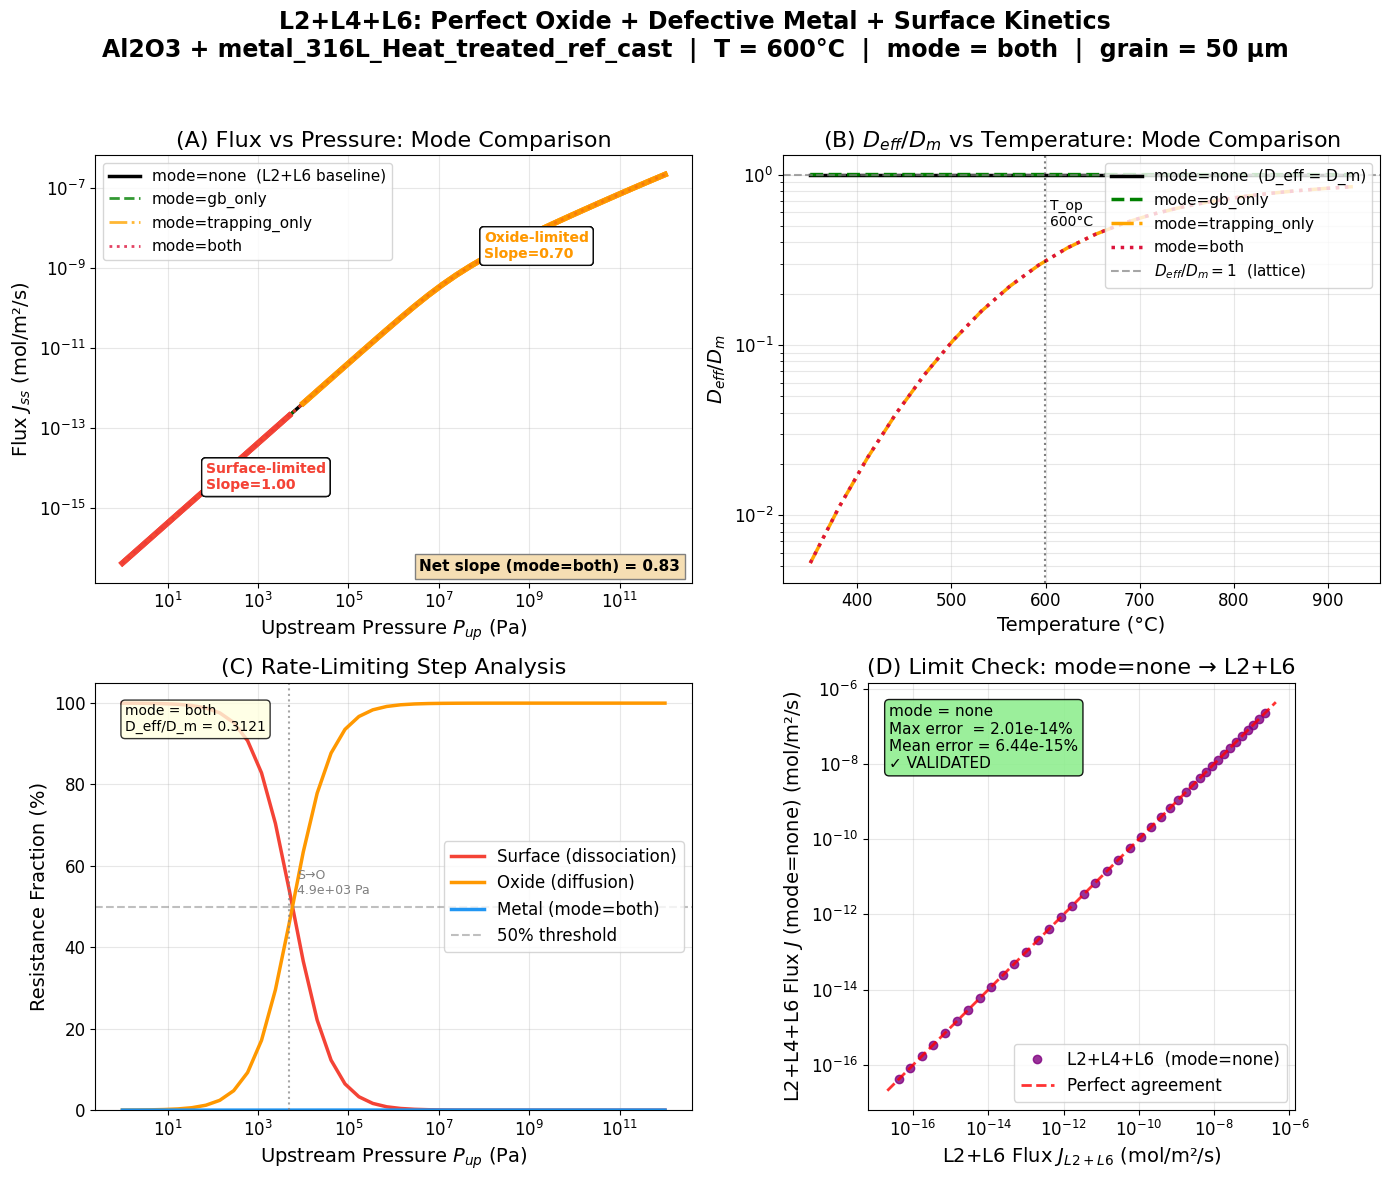


L2+L4+L6 FIGURE 1 — VALIDATION SUMMARY
  Net log-log slope (mode=both): 0.8349
  D_eff/D_m at T_op:
    mode=none            1.0000
    mode=gb_only         1.0015
    mode=trapping_only   0.3116
    mode=both            0.3121
  Limit check error (mode=none): 2.01e-14%  (✓)
  S→O crossover:  4.92e+03 Pa


In [5]:
# =============================================================================
# CELL 4 — FIGURE 1: Core Validation (2×2)
# =============================================================================
"""
Figure 1 validates the L2+L4+L6 model from four angles at operating
temperature. The key new dimension vs L2+L6 is the microstructure mode.

Panel (A) — Flux vs Pressure: Mode Comparison
    Question: How does each microstructure mode shift the flux curve and
    regime boundaries relative to the pure lattice baseline?
    Four curves: mode='none' (L2+L6 baseline), mode='gb_only' (GB
    short-circuit only), mode='trapping_only' (trapping only),
    mode='both'. Each curve has colored regime overlays and slope
    annotation boxes using the identical pattern from all previous levels.
    mode='none' is the black solid baseline. The other three use
    CURVE_STYLES colors. Net slope annotation box references the active
    config mode.

Panel (B) — D_eff/D_m vs Temperature: Mode Comparison
    Question: How does each microstructure mode change the effective
    diffusivity relative to the lattice value across the temperature range,
    and where does each mode cross D_eff/D_m = 1?
    Sweeps temperature from T_RANGE[0] to T_RANGE[1]. Computes D_eff for
    each mode at each T via get_D_eff_at_T. GBs push ratio above 1 at
    low T (short-circuit). Traps push it below 1 at low T (delayed
    diffusion). The crossover temperature for each mode is annotated.
    Dual x-axis: °C bottom, K top.

Panel (C) — Resistance Fractions vs Pressure
    Question: Which step controls the rate at operating conditions?
    Consistent style with all previous levels — semilogx lines per
    fraction, 50% threshold, S→O and O→M crossover vertical lines.
    Uses the active config mode. Annotation box shows mode and D_eff/D_m.

Panel (D) — Limit Check: mode='none' recovers L2+L6
    Question: When microstructure is disabled, does L2+L4+L6 recover
    the L2+L6 result exactly?
    Runs calculate_defective_metal_flux_L6 with mode='none' and compares
    to solve_steady_state_flux_direct. Parity plot. Green box if < 1%.
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle(
    f'L2+L4+L6: Perfect Oxide + Defective Metal + Surface Kinetics\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  '
    f'mode = {mode}  |  grain = {grain_size*1e6:.0f} μm',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ── Regime overlay helper — identical to all previous levels ──────────────────
def plot_regime_overlay(ax, P_arr, J_arr, frac_s, frac_o, frac_m, valid_mask):
    rl = np.where(frac_s > 0.5, 'surface',
         np.where(frac_o > 0.5, 'oxide',
         np.where(frac_m > 0.5, 'metal', 'mixed')))

    region_styles = [
        ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
        ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
        ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
        ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
    ]

    for regime, color, label in region_styles:
        mask = (rl == regime) & valid_mask
        if not np.any(mask):
            continue
        idxs = np.where(mask)[0]
        for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
            group = list(map(itemgetter(1), g))
            if len(group) < 3:
                continue
            P_seg = P_arr[group]
            J_seg = J_arr[group]
            ax.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
            slope_seg, *_ = stats.linregress(
                np.log10(P_seg), np.log10(np.abs(J_seg))
            )
            mid = len(group) // 2
            ax.text(
                P_seg[mid], J_seg[mid],
                f'{label}\nSlope={slope_seg:.2f}',
                color=color,
                fontsize=STYLE['fontsize_annotation']-1,
                fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

# ─────────────────────────────────────────────────────────────────────────────
# (A) FLUX vs PRESSURE — mode comparison
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
P_A = P_RANGE_ARR

mode_cases = [
    ('none',          'black',                              '-',  'mode=none  (L2+L6 baseline)'),
    ('gb_only',       CURVE_STYLES['L4_gb']['color'],       '--', 'mode=gb_only'),
    ('trapping_only', CURVE_STYLES['L4_trap']['color'],     '-.', 'mode=trapping_only'),
    ('both',          CURVE_STYLES['L4_both']['color'],     ':',  'mode=both'),
]

for m, color, ls, label in mode_cases:
    J_m  = np.full(len(P_A), np.nan)
    fs_m = np.full(len(P_A), np.nan)
    fo_m = np.full(len(P_A), np.nan)
    fm_m = np.full(len(P_A), np.nan)

    for i, P_up in enumerate(P_A):
        try:
            r = calculate_defective_metal_flux_L6(
                P_up, P_down,
                L_m,
                T_op,
                k_diss, K_eq,
                D_ox, K_ox, L_ox,
                D_m,
                K_s_m,
                microstructure_params=microstructure,
                mode=m,
            )
            J_m[i]  = r['flux']
            fs_m[i] = r['resistances']['fraction_surface']
            fo_m[i] = r['resistances']['fraction_oxide']
            fm_m[i] = r['resistances']['fraction_metal']
        except Exception:
            pass

    v_m = ~np.isnan(J_m) & (J_m > 0)
    if not np.any(v_m):
        print(f"  ⚠  mode={m}: no valid points")
        continue

    lw    = STYLE['linewidth'] if m == 'none' else STYLE['linewidth'] - 0.5
    alpha_val = 1.0            if m == 'none' else 0.8

    ax1.loglog(
        P_A[v_m], J_m[v_m],
        color=color, ls=ls, lw=lw, alpha=alpha_val,
        label=label
    )
    plot_regime_overlay(ax1, P_A, J_m, fs_m, fo_m, fm_m, v_m)

# Net slope annotation
v_net = ~np.isnan(J_arr) & (J_arr > 0)
if np.sum(v_net) > 2:
    slope_net, *_ = stats.linregress(
        np.log10(P_RANGE_ARR[v_net]),
        np.log10(np.abs(J_arr[v_net]))
    )
    ax1.text(
        0.98, 0.02, f'Net slope (mode={mode}) = {slope_net:.2f}',
        transform=ax1.transAxes, ha='right', va='bottom',
        fontsize=STYLE['fontsize_annotation'], fontweight='bold',
        bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
    )
else:
    slope_net = np.nan

ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',      fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',              fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure: Mode Comparison', fontsize=STYLE['fontsize_title'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (B) D_eff/D_m vs TEMPERATURE — mode comparison
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)

mode_D_styles = [
    ('none',          'black',                              '-',  'mode=none  (D_eff = D_m)'),
    ('gb_only',       CURVE_STYLES['L4_gb']['color'],       '--', 'mode=gb_only'),
    ('trapping_only', CURVE_STYLES['L4_trap']['color'],     '-.', 'mode=trapping_only'),
    ('both',          CURVE_STYLES['L4_both']['color'],     ':',  'mode=both'),
]

for m, color, ls, label in mode_D_styles:
    ratio_arr = np.full(N_T, np.nan)

    for j, T_K in enumerate(temperatures_K):
        D_latt  = get_D_m_at_T(T_K)
        D_eff_j = get_D_eff_at_T(T_K, m, microstructure)
        if D_latt > 0:
            ratio_arr[j] = D_eff_j / D_latt

    v_r = ~np.isnan(ratio_arr)
    if not np.any(v_r):
        continue

    ax2.semilogy(
        temperatures_K[v_r] - 273.15, ratio_arr[v_r],
        color=color, ls=ls, lw=STYLE['linewidth'],
        label=label
    )

    # Annotate crossover where ratio crosses 1
    if m in ('gb_only', 'both'):
        cross = np.where(np.diff(np.sign(ratio_arr[v_r] - 1.0)))[0]
        if len(cross) > 0:
            T_cross = temperatures_K[v_r][cross[0]] - 273.15
            ax2.axvline(T_cross, color=color, ls=':', lw=1.5, alpha=0.6)
            ax2.text(
                T_cross + 5, 2.0,
                f'{T_cross:.0f}°C',
                color=color, fontsize=STYLE['fontsize_annotation']-1
            )

# Unity reference line
ax2.axhline(
    1.0, color='gray', ls='--', lw=1.5, alpha=0.7,
    label='$D_{eff}/D_m = 1$  (lattice)'
)

# T_op marker
ax2.axvline(
    T_op - 273.15, color='black', ls=':', lw=1.5, alpha=0.5
)
ax2.text(
    T_op - 273.15 + 5, 0.5,
    f'T_op\n{T_op-273.15:.0f}°C',
    fontsize=STYLE['fontsize_annotation']-1, color='black'
)

ax2.set_xlabel('Temperature (°C)',      fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('$D_{eff}/D_m$',         fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) $D_{eff}/D_m$ vs Temperature: Mode Comparison',
              fontsize=STYLE['fontsize_title'])
ax2.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (C) RESISTANCE FRACTIONS vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.semilogx(
    P_RANGE_ARR[valid], frac_surface_arr[valid] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface (dissociation)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_oxide_arr[valid] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide (diffusion)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_metal_arr[valid] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label=f'Metal (mode={mode})'
)
ax3.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if P_cross_surf_oxide is not None:
    ax3.axvline(P_cross_surf_oxide, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_surf_oxide * 1.5, 53,
        f'S→O\n{P_cross_surf_oxide:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )
if P_cross_oxide_metal is not None:
    ax3.axvline(P_cross_oxide_metal, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_oxide_metal * 1.5, 53,
        f'O→M\n{P_cross_oxide_metal:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )

if P_cross_surf_oxide is None and P_cross_oxide_metal is None:
    dominant = ('Surface' if n_surface >= n_oxide and n_surface >= n_metal
                else 'Oxide' if n_oxide >= n_metal else 'Metal')
    ax3.text(
        0.05, 0.50,
        f'No crossover in range\n{dominant}-limited throughout',
        transform=ax3.transAxes,
        fontsize=STYLE['fontsize_annotation'],
        va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax3.text(
    0.05, 0.95,
    f'mode = {mode}\nD_eff/D_m = {D_eff/D_m:.4f}',
    transform=ax3.transAxes,
    fontsize=STYLE['fontsize_annotation']-1, va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax3.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Rate-Limiting Step Analysis',   fontsize=STYLE['fontsize_title'])
ax3.set_ylim(0, 105)
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (D) LIMIT CHECK — mode='none' recovers L2+L6
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

P_D    = P_RANGE_ARR
J_none = np.full(len(P_D), np.nan)
J_L2L6 = np.full(len(P_D), np.nan)

for i, P_up in enumerate(P_D):
    try:
        r_none = calculate_defective_metal_flux_L6(
            P_up, P_down,
            L_m,
            T_op,
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m,
            K_s_m,
            microstructure_params=microstructure,
            mode='none',
        )
        J_none[i] = r_none['flux']
    except Exception:
        pass

    try:
        r_L2L6 = solve_steady_state_flux_direct(
            P_up, P_down, L_m,
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m, K_s_m
        )
        J_L2L6[i] = r_L2L6['J_ss']
    except Exception:
        pass

valid_parity = (~np.isnan(J_none) & ~np.isnan(J_L2L6) &
                (J_none > 0) & (J_L2L6 > 0))

if np.any(valid_parity):
    ax4.loglog(
        J_L2L6[valid_parity], J_none[valid_parity],
        'o', color=CURVE_STYLES['L2_L6']['color'],
        markersize=6, alpha=0.8,
        label='L2+L4+L6  (mode=none)'
    )

    J_min = min(J_L2L6[valid_parity].min(), J_none[valid_parity].min()) * 0.5
    J_max = max(J_L2L6[valid_parity].max(), J_none[valid_parity].max()) * 2.0
    ax4.loglog(
        [J_min, J_max], [J_min, J_max],
        color=CURVE_STYLES['parity']['color'],
        ls=CURVE_STYLES['parity']['ls'],
        lw=CURVE_STYLES['parity']['lw'],
        alpha=CURVE_STYLES['parity']['alpha'],
        label='Perfect agreement'
    )

    rel_errors = (np.abs(J_none[valid_parity] - J_L2L6[valid_parity])
                  / J_L2L6[valid_parity] * 100)
    max_err   = rel_errors.max()
    mean_err  = rel_errors.mean()
    box_color = 'lightgreen' if max_err < 1.0 else 'lightyellow'

    ax4.text(
        0.05, 0.95,
        f'mode = none\n'
        f'Max error  = {max_err:.2e}%\n'
        f'Mean error = {mean_err:.2e}%\n'
        f'{"✓ VALIDATED" if max_err < 1.0 else "⚠ CHECK"}',
        transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
        va='top',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9)
    )
else:
    max_err  = np.nan
    mean_err = np.nan
    ax4.text(
        0.5, 0.5, 'No valid parity points\nCheck solver',
        transform=ax4.transAxes, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax4.set_xlabel('L2+L6 Flux $J_{L2+L6}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('L2+L4+L6 Flux $J$ (mode=none) (mol/m²/s)',  fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Limit Check: mode=none → L2+L6',          fontsize=STYLE['fontsize_title'])
ax4.set_aspect('equal', adjustable='box')
ax4.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L2+L4+L6 FIGURE 1 — VALIDATION SUMMARY")
print("=" * 60)
if not np.isnan(slope_net):
    print(f"  Net log-log slope (mode={mode}): {slope_net:.4f}")
print(f"  D_eff/D_m at T_op:")
for m, D in D_eff_modes.items():
    print(f"    mode={m:<14}  {D/D_m:.4f}")
print(f"  Limit check error (mode=none): {max_err:.2e}%  "
      f"({'✓' if not np.isnan(max_err) and max_err < 1.0 else '⚠'})")
if P_cross_surf_oxide is not None:
    print(f"  S→O crossover:  {P_cross_surf_oxide:.2e} Pa")
if P_cross_oxide_metal is not None:
    print(f"  O→M crossover:  {P_cross_oxide_metal:.2e} Pa")
print("=" * 60)

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1410: UserWarning: GB volume fraction 15.00% > 10%. GB network percolation effects become important. Consider using Hart model instead of parallel.
  warnings.warn(f"GB volume fraction {f_gb:.2%} > 10%. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1410: UserWarning: GB volume fraction 10.09% > 10%. GB network percolation effects become important. Consider using Hart model instead of parallel.
  warnings.warn(f"GB volume fraction {f_gb:.2%} > 10%. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (3.23×) and trapping (0.31×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)


  ⚠  metal: P_for_metal_Ea is None — fit skipped


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 623.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 5.22e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 767.2 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'grain_boundaries' has occupancy θ

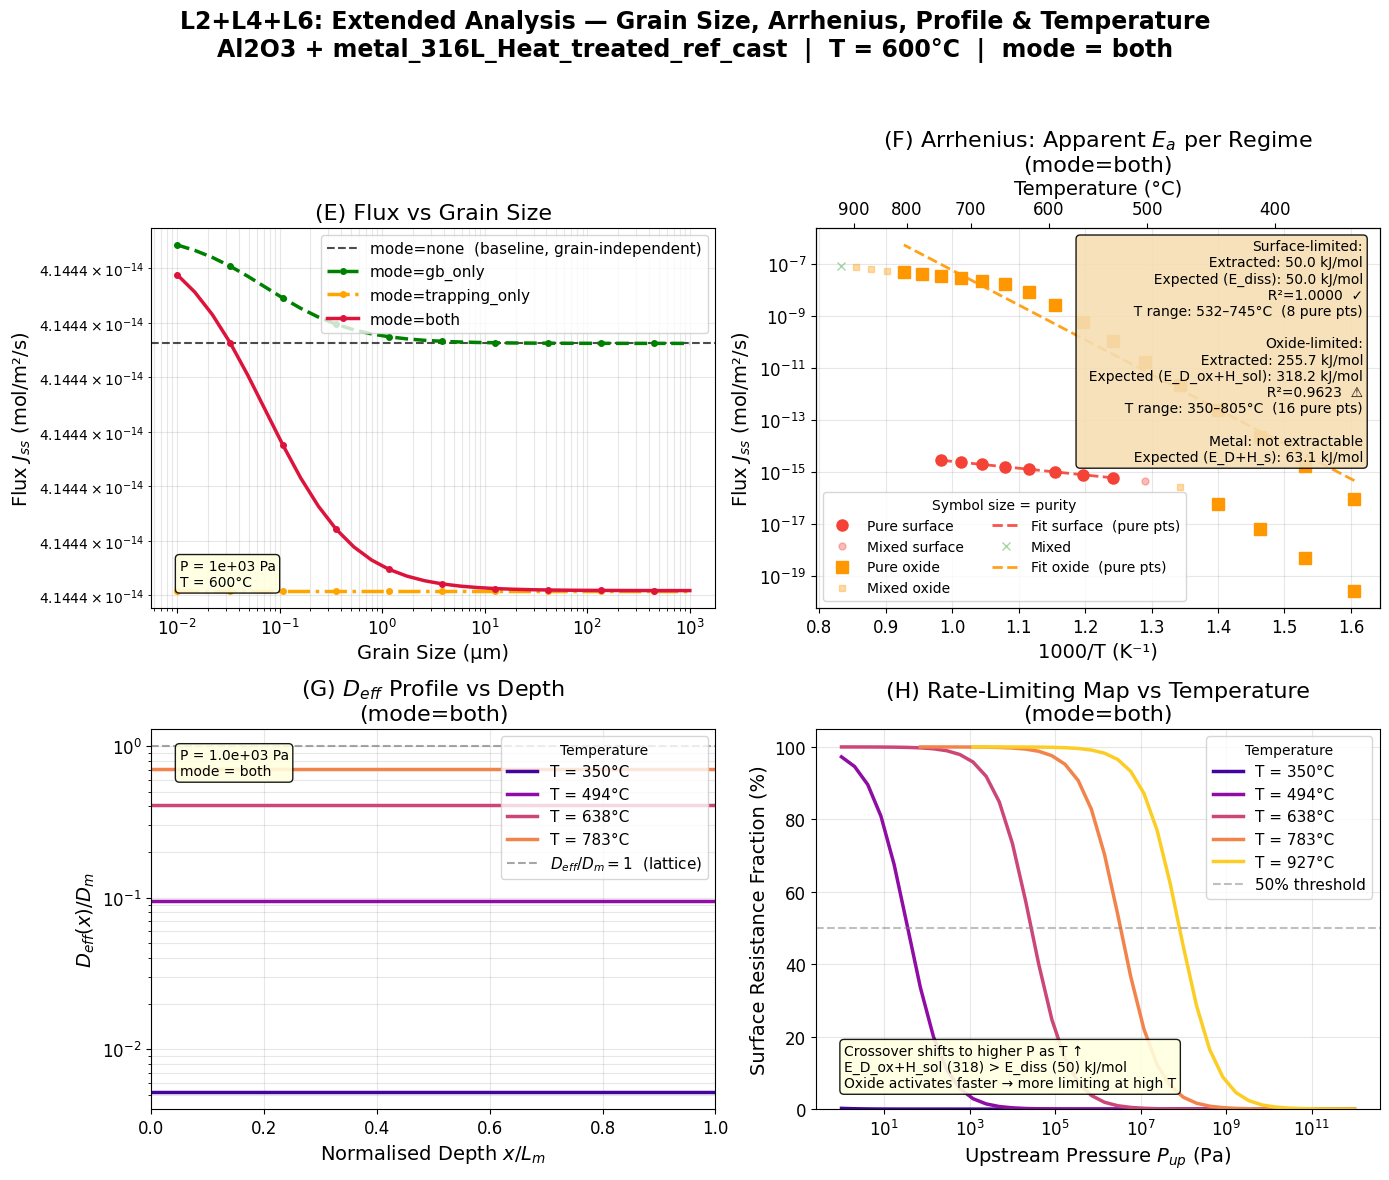


L2+L4+L6 FIGURE 2 — SUMMARY
  mode = both

  Arrhenius results:
    Surface: extracted=50.0  expected=50.0 kJ/mol  shift=+0.0 kJ/mol  (✓)  8 pure pts
    Oxide: extracted=255.7  expected=318.2 kJ/mol  shift=-62.5 kJ/mol  (⚠)  16 pure pts
    Metal: not extractable

  Crossover pressures across T sweep:
    T = 494°C  →  P_crossover = 3.46e+01 Pa
    T = 638°C  →  P_crossover = 2.03e+04 Pa
    T = 783°C  →  P_crossover = 2.89e+06 Pa
    T = 927°C  →  P_crossover = 4.92e+07 Pa


In [6]:
# =============================================================================
# CELL 5 — FIGURE 2: Extended Analysis (2×2)
# =============================================================================
"""
Figure 2 examines grain size sensitivity, activation energies, D_eff
spatial profile, and temperature effects on the rate-limiting balance.

Panel (E) — Flux vs Grain Size
    Question: How does grain size change the flux for each microstructure
    mode, and at what grain size does the microstructure effect saturate?
    Fixed T and P (from VALIDATION['L4']). Sweeps grain_size from
    grain_size_sweep range in config. Three curves — mode='gb_only',
    mode='trapping_only', mode='both'. mode='none' is the horizontal
    baseline (grain-size independent). Log-log plot. Shows flux saturates
    at large grain sizes (bulk lattice limit) and diverges from the
    baseline at small grain sizes where GB area fraction dominates.
    The grain size where each mode crosses 10% deviation from baseline
    is annotated.

Panel (F) — Arrhenius: apparent Ea per regime, classified by purity
    Question: Does the model extract the correct activation energy in each
    regime, and does microstructure shift the apparent Ea vs the pure
    lattice reference?
    Same five-category classification approach as all previous levels.
    Uses calculate_defective_metal_flux_L6 with active config mode at
    each T. Resistance fractions from the solver result. Dashed fit line
    through pure points only. Annotation box shows extracted vs expected
    Ea and T range used. The metal regime apparent Ea is expected to
    shift from E_D+H_s when microstructure is active — this panel
    quantifies that shift.

Panel (G) — D_eff Profile vs Metal Depth at Multiple T
    Question: How does D_eff vary through the metal thickness at different
    temperatures, and does the concentration gradient create a meaningful
    D_eff profile?
    Runs the solver at P_for_metal_Ea (or fallback P) at 5 temperatures.
    Extracts the D_eff spatial profile (x vs D) from r['profiles'].
    Plots D_eff/D_m vs normalised depth x/L_m for each temperature using
    plasma colormap. A flat profile means D_eff is concentration-
    independent at that T. A gradient means the inlet concentration
    is high enough to change trap occupancy or GB contribution across
    the thickness.

Panel (H) — Rate-Limiting Map vs Temperature
    Question: How does the surface/oxide/metal resistance balance shift
    as temperature increases for the active config mode?
    Runs the full pressure sweep at 5 temperatures. Plots surface
    resistance fraction (%) vs pressure using plasma colormap.
    Consistent style with all previous levels. Crossover shift direction
    annotated with physical reason from config activation energies.
"""

fig2, axes2 = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig2.suptitle(
    f'L2+L4+L6: Extended Analysis — Grain Size, Arrhenius, Profile & Temperature\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  mode = {mode}',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (E) FLUX vs GRAIN SIZE
# ─────────────────────────────────────────────────────────────────────────────
ax_E = axes2[0, 0]

P_fixed_E = VAL_L4['P_fixed']

# mode='none' baseline — grain-size independent
try:
    r_base_E = calculate_defective_metal_flux_L6(
        P_fixed_E, P_down,
        L_m, T_grain_size,
        k_diss, K_eq,
        D_ox, K_ox, L_ox,
        D_m, K_s_m,
        microstructure_params=microstructure,
        mode='none',
    )
    J_baseline_E = r_base_E['flux']
except Exception:
    J_baseline_E = np.nan

if not np.isnan(J_baseline_E):
    ax_E.axhline(
        J_baseline_E, color='black', ls='--', lw=1.5, alpha=0.7,
        label='mode=none  (baseline, grain-independent)'
    )

grain_mode_styles = [
    ('gb_only',       CURVE_STYLES['L4_gb']['color'],   '--', 'mode=gb_only'),
    ('trapping_only', CURVE_STYLES['L4_trap']['color'], '-.', 'mode=trapping_only'),
    ('both',          CURVE_STYLES['L4_both']['color'], '-',  'mode=both'),
]

for m, color, ls, label in grain_mode_styles:
    J_gs = np.full(len(grain_size_sweep), np.nan)

    for i, gs in enumerate(grain_size_sweep):
        ms_gs = {**microstructure, 'grain_size': gs}
        try:
            r = calculate_defective_metal_flux_L6(
                P_fixed_E, P_down,
                L_m, T_grain_size,
                k_diss, K_eq,
                D_ox, K_ox, L_ox,
                D_m, K_s_m,
                microstructure_params=ms_gs,
                mode=m,
            )
            J_gs[i] = r['flux']
        except Exception:
            pass

    v_gs = ~np.isnan(J_gs) & (J_gs > 0)
    if not np.any(v_gs):
        print(f"  ⚠  mode={m}: no valid grain size points")
        continue

    ax_E.loglog(
        grain_size_sweep[v_gs] * 1e6, J_gs[v_gs],
        color=color, ls=ls, lw=STYLE['linewidth'],
        marker='o', ms=4, markevery=3,
        label=label
    )

    # Annotate grain size where deviation from baseline exceeds 10%
    if not np.isnan(J_baseline_E):
        dev = np.abs(J_gs[v_gs] - J_baseline_E) / J_baseline_E
        cross_10 = np.where(dev > 0.10)[0]
        if len(cross_10) > 0:
            gs_cross = grain_size_sweep[v_gs][cross_10[-1]]
            ax_E.axvline(
                gs_cross * 1e6, color=color, ls=':', lw=1.5, alpha=0.5
            )
            ax_E.text(
                gs_cross * 1e6, J_gs[v_gs][cross_10[-1]] * 1.5,
                f'{gs_cross*1e6:.0f} μm',
                color=color, fontsize=STYLE['fontsize_annotation']-1
            )

ax_E.text(
    0.05, 0.05,
    f'P = {P_fixed_E:.0e} Pa\nT = {T_grain_size-273.15:.0f}°C',
    transform=ax_E.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='bottom',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)

ax_E.set_xlabel('Grain Size (μm)',            fontsize=STYLE['fontsize_axis'])
ax_E.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',   fontsize=STYLE['fontsize_axis'])
ax_E.set_title('(E) Flux vs Grain Size',       fontsize=STYLE['fontsize_title'])
ax_E.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax_E.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_E.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (F) ARRHENIUS — apparent Ea per regime, classified by purity
# ─────────────────────────────────────────────────────────────────────────────
ax_F = axes2[0, 1]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)
inv_T          = 1000.0 / temperatures_K

def classify_regime(fs, fo, fm, pure_thresh=0.90, mixed_thresh=0.50):
    if fs >= pure_thresh:    return 'pure_surface'
    elif fo >= pure_thresh:  return 'pure_oxide'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_oxide':    {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide':   {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 5,  'alpha': 0.35},
    'pure_metal':    {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal':   {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],
                      'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

regime_Ea_cases = [
    ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color']),
    ('oxide',   P_for_oxide_Ea,   CURVE_STYLES['oxide_region']['color']),
    ('metal',   P_for_metal_Ea,   CURVE_STYLES['metal_region']['color']),
]

arrhenius_results  = {}
plotted_cls_labels = set()

for label, P_fixed, color in regime_Ea_cases:
    if P_fixed is None:
        print(f"  ⚠  {label}: P_for_{label}_Ea is None — fit skipped")
        arrhenius_results[label] = None
        continue

    J_arr_T   = np.full(N_T, np.nan)
    class_arr = np.empty(N_T, dtype=object)

    for j, T_K in enumerate(temperatures_K):
        try:
            r = calculate_defective_metal_flux_L6(
                P_fixed, P_down,
                L_m,
                T_K,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),
                get_K_s_m_at_T(T_K),
                microstructure_params=microstructure,
                mode=mode,
            )
            J_arr_T[j] = r['flux']
            fs = r['resistances']['fraction_surface']
            fo = r['resistances']['fraction_oxide']
            fm = r['resistances']['fraction_metal']
            class_arr[j] = classify_regime(fs, fo, fm)
        except Exception:
            class_arr[j] = 'mixed'

    pure = (class_arr == f'pure_{label}') & ~np.isnan(J_arr_T) & (J_arr_T > 0)

    # Plot all classified points
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & ~np.isnan(J_arr_T) & (J_arr_T > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax_F.semilogy(
            inv_T[mask], J_arr_T[mask],
            ls='none',
            color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_cls_labels
                  else '_nolegend_'
        )
        plotted_cls_labels.add(cls_label)

    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points — fit skipped")
        arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_arr_T[pure])
    )
    E_a = -slope * R * 1000

    arrhenius_results[label] = {
        'J': J_arr_T, 'valid': pure,
        'slope': slope, 'intercept': intercept,
        'r_sq': r_val**2, 'E_a': E_a,
        'P_fixed': P_fixed, 'color': color,
        'n_pure': int(np.sum(pure)),
        'T_pure_range': (temperatures_K[pure].min() - 273.15,
                         temperatures_K[pure].max() - 273.15),
    }

    ax_F.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=color, ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label}  (pure pts)'
    )

# Dual x-axis
ax_F_top = ax_F.twiny()
ax_F_top.set_xlim(ax_F.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
if np.any(in_range):
    ax_F_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_F_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_F_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_F_top.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box
E_refs    = {'surface': E_REF_SURFACE, 'oxide': E_REF_OXIDE, 'metal': E_REF_METAL}
ref_names = {'surface': 'E_diss', 'oxide': 'E_D_ox+H_sol', 'metal': 'E_D+H_s'}
annot     = []
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    rn  = ref_names[lbl]
    if res is None:
        annot.append(f'{lbl.capitalize()}: not extractable')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_r) < 3000
        annot.append(f'{lbl.capitalize()}-limited:')
        annot.append(f'  Extracted: {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
        annot.append(f'  R²={res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_pure_range"][0]:.0f}–'
                     f'{res["T_pure_range"][1]:.0f}°C  '
                     f'({res["n_pure"]} pure pts)')
    annot.append('')

ax_F.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax_F.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)
ax_F.set_xlabel('1000/T (K⁻¹)',             fontsize=STYLE['fontsize_axis'])
ax_F.set_ylabel('Flux $J_{ss}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax_F.set_title(f'(F) Arrhenius: Apparent $E_a$ per Regime\n(mode={mode})',
               fontsize=STYLE['fontsize_title'])
ax_F.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',
            ncol=2, title='Symbol size = purity')
ax_F.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_F.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (G) D_eff PROFILE vs METAL DEPTH at multiple T
# ─────────────────────────────────────────────────────────────────────────────
ax_G = axes2[1, 0]

T_profile_values = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors_G       = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_profile_values)))

# Use P_for_metal_Ea if available, else fallback to P_fixed_E
P_profile = P_for_metal_Ea if P_for_metal_Ea is not None else P_fixed_E

for T_K, col in zip(T_profile_values, T_colors_G):
    try:
        r_prof = calculate_defective_metal_flux_L6(
            P_profile, P_down,
            L_m,
            T_K,
            get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
            get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
            get_D_m_at_T(T_K),
            get_K_s_m_at_T(T_K),
            microstructure_params=microstructure,
            mode=mode,
        )

        profiles = r_prof.get('profiles', {})
        x_arr    = profiles.get('x', None)
        D_arr    = profiles.get('D', None)
        D_latt_T = get_D_m_at_T(T_K)

        if x_arr is None or D_arr is None:
            continue

        x_norm   = x_arr / L_m
        ratio_arr = D_arr / D_latt_T

        ax_G.semilogy(
            x_norm, ratio_arr,
            color=col, lw=STYLE['linewidth'],
            label=f'T = {T_K-273.15:.0f}°C'
        )

    except Exception:
        pass

ax_G.axhline(
    1.0, color='gray', ls='--', lw=1.5, alpha=0.7,
    label='$D_{eff}/D_m = 1$  (lattice)'
)

ax_G.text(
    0.05, 0.95,
    f'P = {P_profile:.1e} Pa\nmode = {mode}',
    transform=ax_G.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)

ax_G.set_xlabel('Normalised Depth $x/L_m$',   fontsize=STYLE['fontsize_axis'])
ax_G.set_ylabel('$D_{eff}(x)/D_m$',           fontsize=STYLE['fontsize_axis'])
ax_G.set_title(f'(G) $D_{{eff}}$ Profile vs Depth\n(mode={mode})',
               fontsize=STYLE['fontsize_title'])
ax_G.set_xlim(0, 1)
ax_G.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_G.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_G.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (H) RATE-LIMITING MAP vs TEMPERATURE
# ─────────────────────────────────────────────────────────────────────────────
ax_H = axes2[1, 1]

T_map_values        = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors_map        = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_map_values)))
crossover_pressures = []

P_H = np.logspace(0, 12, 40)

for T_K, col in zip(T_map_values, T_colors_map):
    fs_row = np.full(len(P_H), np.nan)

    for i, P_up in enumerate(P_H):
        try:
            r = calculate_defective_metal_flux_L6(
                P_up, P_down,
                L_m,
                T_K,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),
                get_K_s_m_at_T(T_K),
                microstructure_params=microstructure,
                mode=mode,
            )
            fs_row[i] = r['resistances']['fraction_surface'] * 100
        except Exception:
            pass

    valid_row = ~np.isnan(fs_row)
    if not np.any(valid_row):
        continue

    ax_H.semilogx(
        P_H[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f}°C'
    )

    sc = np.where(np.diff(np.sign(fs_row[valid_row] - 50)))[0]
    if len(sc) > 0:
        idx  = sc[0]
        fs_v = fs_row[valid_row]
        if idx + 1 < len(fs_v) and fs_v[idx] > 50 and fs_v[idx+1] < 50:
            crossover_pressures.append((T_K, P_H[valid_row][idx]))

ax_H.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]
    if P_co_high < P_co_low:
        direction = 'lower P as T ↑'
        physical  = (f'E_diss ({E_REF_SURFACE/1000:.0f}) > '
                     f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) kJ/mol')
        meaning   = 'Surface activates faster → less limiting at high T'
    else:
        direction = 'higher P as T ↑'
        physical  = (f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) > '
                     f'E_diss ({E_REF_SURFACE/1000:.0f}) kJ/mol')
        meaning   = 'Oxide activates faster → more limiting at high T'
    ax_H.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n{physical}\n{meaning}',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    ax_H.text(
        0.05, 0.05,
        f'No crossover at any T\nSystem is {dominant}\nacross full pressure range',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax_H.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_title(f'(H) Rate-Limiting Map vs Temperature\n(mode={mode})',
               fontsize=STYLE['fontsize_title'])
ax_H.set_ylim(0, 105)
ax_H.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_H.grid(True, alpha=STYLE['grid_alpha'])
ax_H.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L2+L4+L6 FIGURE 2 — SUMMARY")
print("=" * 60)
print(f"  mode = {mode}")
print(f"\n  Arrhenius results:")
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    if res is None:
        print(f"    {lbl.capitalize()}: not extractable")
    else:
        match = abs(res['E_a'] - E_r) < 3000
        shift = res['E_a'] - E_r
        print(f"    {lbl.capitalize()}: extracted={res['E_a']/1000:.1f}  "
              f"expected={E_r/1000:.1f} kJ/mol  "
              f"shift={shift/1000:+.1f} kJ/mol  "
              f"({'✓' if match else '⚠'})  "
              f"{res['n_pure']} pure pts")
if crossover_pressures:
    print(f"\n  Crossover pressures across T sweep:")
    for T_K, P_co in crossover_pressures:
        print(f"    T = {T_K-273.15:.0f}°C  →  P_crossover = {P_co:.2e} Pa")
print("=" * 60)

In [7]:
# =============================================================================
# CELL 6 — DATAFRAME OUTPUT
# =============================================================================
df = pd.DataFrame(rows)

df_display = df.copy()
for col in df_display.columns:
    if col in ('Rate-Limiting', 'mode', 'Error'):
        continue
    if df_display[col].dtype == float:
        if 'fraction' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'theta' in col.lower():
            df_display[col] = df_display[col].round(6)
        elif 'D_eff/D_m' in col:
            df_display[col] = df_display[col].round(6)
        else:
            df_display[col] = df_display[col].apply(
                lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
            )

n_surface_df = (df['Rate-Limiting'] == 'SURFACE').sum()
n_oxide_df   = (df['Rate-Limiting'] == 'OXIDE').sum()
n_metal_df   = (df['Rate-Limiting'] == 'METAL').sum()
n_mixed_df   = (df['Rate-Limiting'] == 'MIXED').sum()
n_error_df   = (df['Rate-Limiting'] == 'ERROR').sum()

print("=" * 60)
print("L2+L4+L6 RESULTS DATAFRAME")
print("=" * 60)
print(f"  Oxide:           {OXIDE_KEY}")
print(f"  Metal:           {METAL_KEY}")
print(f"  T:               {T_op-273.15:.0f}°C  ({T_op} K)")
print(f"  L_ox:            {L_ox*1e6:.1f} μm")
print(f"  L_m:             {L_m*1e3:.1f} mm")
print(f"  mode:            {mode}")
print(f"  grain_size:      {grain_size*1e6:.1f} μm")
print(f"  k_diss:          {k_diss:.3e}  mol/m²/s/Pa")
print(f"  K_eq:            {K_eq:.3e}  Pa⁻¹")
print(f"  α:               {alpha:.3e}  mol/m²/s/Pa^0.5  (oxide)")
print(f"  β_latt:          {beta_L:.3e}  mol/m²/s/Pa^0.5  (lattice)")
print(f"  β_eff:           {beta_eff:.3e}  mol/m²/s/Pa^0.5  (mode={mode})")
print(f"  D_eff/D_m:       {D_eff/D_m:.6f}")

print(f"\n  Total rows:        {len(df)}")
print(f"\n  Resistance regime:")
print(f"    Surface-limited: {n_surface_df}")
print(f"    Oxide-limited:   {n_oxide_df}")
print(f"    Metal-limited:   {n_metal_df}")
print(f"    Mixed:           {n_mixed_df}")
if n_error_df > 0:
    print(f"    Errors:          {n_error_df}  ⚠")

# D_eff statistics across pressure sweep
d_eff_col = df.get('D_eff (m²/s)', pd.Series(dtype=float))
if 'D_eff (m²/s)' in df.columns:
    d_vals = df['D_eff (m²/s)'].dropna()
    if len(d_vals) > 0:
        print(f"\n  D_eff across pressure sweep:")
        print(f"    Min:   {d_vals.min():.4e} m²/s")
        print(f"    Max:   {d_vals.max():.4e} m²/s")
        print(f"    Mean:  {d_vals.mean():.4e} m²/s")
        print(f"    D_m:   {D_m:.4e} m²/s")

if 'D_eff/D_m' in df.columns:
    ratio_vals = df['D_eff/D_m'].dropna()
    if len(ratio_vals) > 0:
        print(f"\n  D_eff/D_m range:  "
              f"{ratio_vals.min():.6f} → {ratio_vals.max():.6f}")

print("=" * 60)

display(df_display)

L2+L4+L6 RESULTS DATAFRAME
  Oxide:           Al2O3
  Metal:           metal_316L_Heat_treated_ref_cast
  T:               600°C  (873 K)
  L_ox:            1.0 μm
  L_m:             1.0 mm
  mode:            both
  grain_size:      50.0 μm
  k_diss:          4.145e-17  mol/m²/s/Pa
  K_eq:            2.799e-11  Pa⁻¹
  α:               2.393e-13  mol/m²/s/Pa^0.5  (oxide)
  β_latt:          5.974e-09  mol/m²/s/Pa^0.5  (lattice)
  β_eff:           1.865e-09  mol/m²/s/Pa^0.5  (mode=both)
  D_eff/D_m:       0.312094

  Total rows:        40

  Resistance regime:
    Surface-limited: 13
    Oxide-limited:   27
    Metal-limited:   0
    Mixed:           0

  D_eff across pressure sweep:
    Min:   6.8474e-11 m²/s
    Max:   6.8474e-11 m²/s
    Mean:  6.8474e-11 m²/s
    D_m:   2.1940e-10 m²/s

  D_eff/D_m range:  0.312094 → 0.312094


,P_up (Pa),P_int (Pa),J_ss (mol/m²/s),θ_surface,D_eff (m²/s),D_eff/D_m,α_oxide,β_eff,R_surface,R_oxide,R_metal,R_total,fraction_surface (%),fraction_oxide (%),fraction_metal (%),Rate-Limiting,mode
0,1.0000e+00,4.9410e-16,4.1445e-17,9.1653e-10,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,2.4128e+16,4.1794e+12,5.3633e+08,2.4132e+16,99.98,0.02,0.00,SURFACE,both
1,2.0309e+00,2.0380e-15,8.4172e-17,1.8614e-09,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,1.1880e+16,4.1794e+12,5.3633e+08,1.1885e+16,99.96,0.04,0.00,SURFACE,both
2,4.1246e+00,8.4058e-15,1.7095e-16,3.7803e-09,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,5.8498e+15,4.1794e+12,5.3633e+08,5.8540e+15,99.93,0.07,0.00,SURFACE,both
3,8.3768e+00,3.4671e-14,3.4718e-16,7.6775e-09,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,2.8804e+15,4.1794e+12,5.3633e+08,2.8845e+15,99.86,0.14,0.00,SURFACE,both
4,1.7013e+01,1.4300e-13,7.0509e-16,1.5592e-08,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,1.4183e+15,4.1794e+12,5.3633e+08,1.4224e+15,99.71,0.29,0.00,SURFACE,both
5,3.4551e+01,5.8984e-13,1.4320e-15,3.1667e-08,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,6.9833e+14,4.1794e+12,5.3633e+08,7.0251e+14,99.40,0.59,0.00,SURFACE,both
6,7.0170e+01,2.4329e-12,2.9082e-15,6.4313e-08,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,3.4385e+14,4.1794e+12,5.3633e+08,3.4803e+14,98.80,1.20,0.00,SURFACE,both
7,1.4251e+02,1.0035e-11,5.9063e-15,1.3061e-07,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,1.6931e+14,4.1794e+12,5.3633e+08,1.7349e+14,97.59,2.41,0.00,SURFACE,both
8,2.8943e+02,4.1389e-11,1.1995e-14,2.6526e-07,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,8.3365e+13,4.1794e+12,5.3633e+08,8.7545e+13,95.23,4.77,0.00,SURFACE,both
9,5.8780e+02,1.7071e-10,2.4361e-14,5.3873e-07,6.8474e-11,0.312094,2.3927e-13,1.8645e-09,4.1048e+13,4.1794e+12,5.3633e+08,4.5228e+13,90.76,9.24,0.00,SURFACE,both


> Fast dissoiation should recover sievert law on metal and recover henry law on oxide.
> 